In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1)
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

backend = "torch"
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = backend

import bayesflow as bf
import numpy as np
import matplotlib.pyplot as plt


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
/export/home/vgiusepp/miniconda3/envs/bf_jax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
n_training = 1000             #size of training set
n_trials = 100               #size of the order invariant input of the SetTransformer is (n_trials, 1)
n_test = 10                 #size of test set
n_subject_test = 10          #N_compositional_conditions
n_samples_posterior = 50
n_epochs = 5

def score_log_norm(x, m, s):
    return -(x-m) / s**2

def simulate_(mu, sigma, n_subjects=1, n_trials=1):
    if isinstance(mu, (float, int)):
        mu = np.ones((n_subjects,)) * mu
        sigma = np.ones((n_subjects,)) * sigma
    data = np.zeros((n_subjects, n_trials, 1))
    for j_subject in range(n_subjects):
        for i_trial in range(n_trials):
            data[j_subject, i_trial] = np.random.normal(loc=mu[j_subject], scale=sigma[j_subject])
    if n_subjects == 1 and n_trials == 1:
        data = data[0, 0]
    elif n_subjects == 1:
        data = data[0]
    elif n_trials == 1:
        data = data[:, 0]
    return dict(sim_data=data)

def sample_hierarchical_priors(n_subjects=1):

    #Group level
    mean_mu = np.random.normal(-10, 10)
    mean_sigma = np.random.normal(5, 0.1)

    #Subject level
    mu = np.random.normal(loc=mean_mu, scale=1.0, size=n_subjects)
    sigma = np.random.normal(loc=mean_sigma, scale=0.1, size=n_subjects)
    return dict(mean_mu=mean_mu, 
                mean_sigma=mean_sigma, 
                mu=mu, 
                sigma=sigma)


def prior_global_score(x: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    mean_mu = x["mean_mu"]
    mean_sigma = x["mean_sigma"]
    parts = {
        "mean_mu": score_log_norm(mean_mu, m=0.0, s=10.0),
        "mean_sigma": score_log_norm(mean_sigma, m=5.0, s=1.0),
    }
    return parts



simulator_hierarchical = bf.simulators.make_simulator([sample_hierarchical_priors, simulate_])
training_data = simulator_hierarchical.sample((n_training), n_trials=n_trials)

#let's create a random mask, the SetTrasnformer will be trained with a variable number of permutationally invariant observation
min_valid_fraction = 0.5    #at least 50% of the observation are valid
max_valid_fraction = 1.0    #at most 100% of the observation are valid
attention_mask_training = np.zeros((n_training, n_trials), dtype=np.float32)
B = n_training
T = 1
S = n_trials 
attention_mask_training = np.zeros((B, T, S), dtype=np.bool_)
for b in range(B):
    for t in range(T):
        valid_fraction = np.random.uniform(min_valid_fraction, max_valid_fraction)
        n_valid = int(S * valid_fraction)
        valid_idx = np.random.choice(S, n_valid, replace=False)
        attention_mask_training[b, t, valid_idx] = True
        
training_data['attention_mask'] = attention_mask_training
print('training attention mask shape', training_data['attention_mask'].shape)

param_names_global = ["mean_mu", "mean_sigma"]
adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .concatenate(param_names_global, into="inference_variables")
    .rename("sim_data", "summary_variables")
)
workflow_global = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=bf.networks.SetTransformer(summary_dim=16, dropout=0.1),
    inference_network=bf.networks.CompositionalDiffusionModel(),
)


# def fun_1(batch):
    # print(f'Shapes of keys in batch: {[ (k, v.shape) for k, v in batch.items() ]}')
    # Create random data of the same shape (512, 100, 1)
    # sim_data = batch['sim_data']
    # random_data = np.random.normal(size=sim_data.shape)

    # # Concatenate along the last axis to get (512, 100, 2)
    # sim_data_aug = np.concatenate([sim_data, random_data], axis=-1)
    # batch['sim_data'] = sim_data_aug
    # return batch
    # pass

# def fun_2(batch):
#     pass


augmentation = [fun_1, fun_2]
training_data = {k: v[:int(len(v) * 0.8)] for k, v in training_data.items()}
validation_data = {k: v[int(len(v) * 0.8):] for k, v in training_data.items()}

history = workflow_global.fit_offline(
        training_data,
        epochs=n_epochs,
        batch_size=512,
        verbose=2,
        validation_data=validation_data,
        # augmentations = fun_1,
        )



INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


training attention mask shape (1000, 1, 100)
Epoch 1/5


ValueError: Exception encountered when calling SetAttention.call().

[1mInput 0 with name 'None' of layer 'input_projector' is incompatible with the layer: expected axis -1 of input shape to have value 2, but received input with shape (160, 100, 1)[0m

Arguments received by SetAttention.call():
  • x=torch.Tensor(shape=torch.Size([160, 100, 1]), dtype=float32)
  • training=False
  • attention_mask=None
  • kwargs=<class 'inspect._empty'>

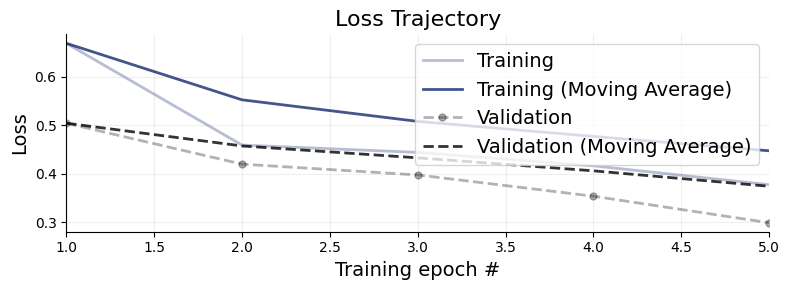

In [ ]:
bf.diagnostics.plots.loss(history, figsize=(8, 3));

In [3]:
#TESTING USING MORE SUBJECTS=N_compositional_conditions
test_data = simulator_hierarchical.sample(n_test, n_subjects=n_subject_test, n_trials=n_trials, )
print('test data shape', test_data['sim_data'].shape)

#same as for the training set, we are going to use a mask for the SetTransformer
# Create mask with shape (N_TEST, N_SUBJECTS, N_PARTICLES) first

B = n_test * n_subject_test
T = 1
S = n_trials 
attention_mask_test = np.zeros((B, T, S), dtype=np.bool_)
min_valid_fraction = 0.0    #at least 50% of the observation are valid
max_valid_fraction = 0.5    #at most 100% of the observation are valid
for b in range(B):
    for t in range(T):
        valid_fraction = np.random.uniform(min_valid_fraction, max_valid_fraction)
        n_valid = int(S * valid_fraction)
        valid_idx = np.random.choice(S, n_valid, replace=False)
        attention_mask_test[b, t, valid_idx] = True

print('attention mask test shape', attention_mask_test.shape)
print('The kwargs string and attention mask cannot be passed together, need to use first workflow_global.approximator.inference_network.integrate_kwargs.update')
# Possible step in the right direction to avoid mixing tensor and non tensor kwargs as suggest by @Jonas aruda
workflow_global.approximator.inference_network.integrate_kwargs.update({
        'method': 'two_step_adaptive',
        'steps': 'adaptive',
        'compositional_bridge_d1': 1/n_subject_test,
        'mini_batch_size': n_subject_test,
        })

global_posterior = workflow_global.compositional_sample(
    num_samples=n_samples_posterior,
    conditions={'sim_data': test_data['sim_data']},
    compute_prior_score=prior_global_score,
    # kwargs={'attention_mask': attention_mask_test},
)



test data shape (10, 10, 100, 1)
attention mask test shape (100, 1, 100)
The kwargs string and attention mask cannot be passed together, need to use first workflow_global.approximator.inference_network.integrate_kwargs.update


Compositional Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Compositional Sampling: 100%|██████████| 1/1 [00:09<00:00,  9.39s/batch]
INFO:bayesflow:Sampling completed in 9.40 seconds.


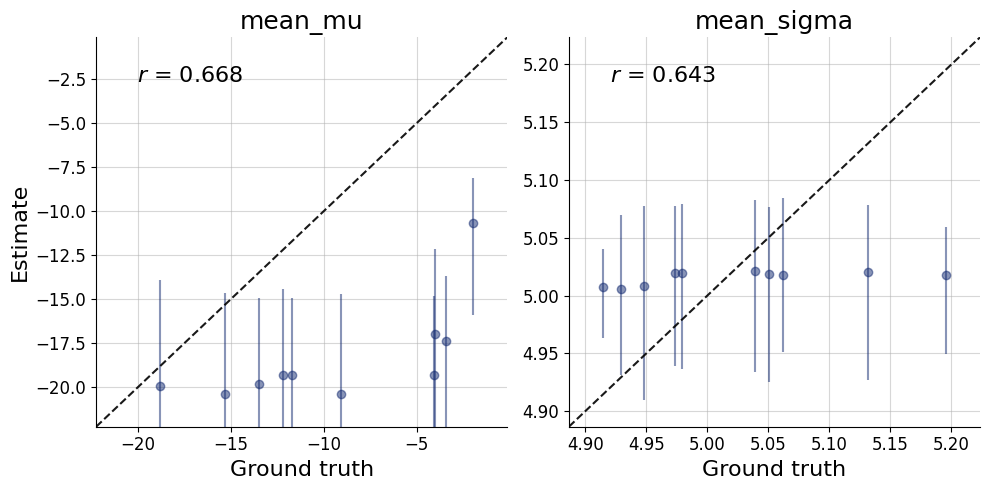

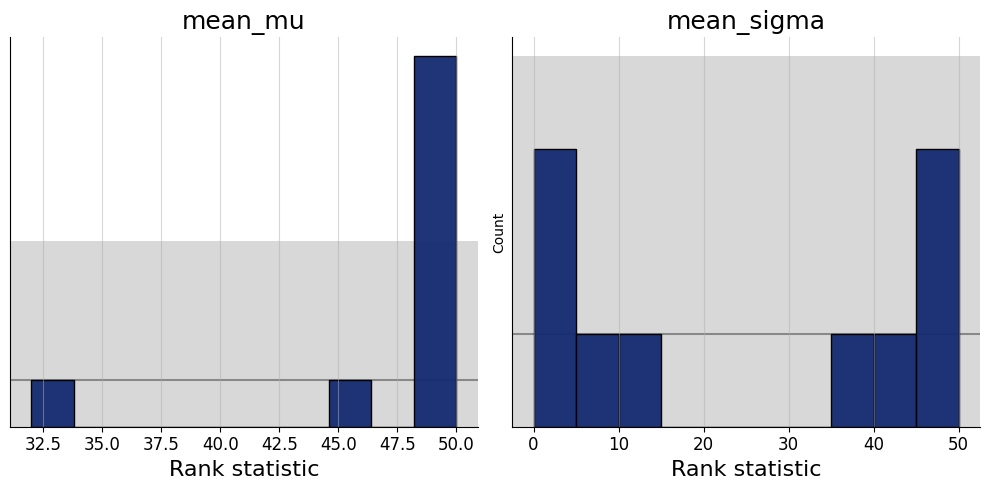

In [4]:
fig = bf.diagnostics.recovery(
        estimates=global_posterior,
        targets=test_data,
        # variable_names=cfg.paramater_global_pretty
        variable_names = param_names_global
    )
plt.show()

fig = bf.diagnostics.calibration_histogram(
        estimates=global_posterior,
        targets=test_data,
        # variable_names=param_names_global
    )

In [11]:
print('test data keys:', list(test_data.keys()))
print('global posterior keys:', list(global_posterior.keys()))

test data keys: ['mean_mu', 'mean_sigma', 'mu', 'sigma', 'sim_data']
global posterior keys: ['mean_mu', 'mean_sigma']
